<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 110.2 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 99.5 MB/s eta 0:00:00


In [3]:
!pip install seaborn

In [2]:
!pip install numpy

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-07-10 12:32:48--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  34.7MB/s    in 4.3s    

2026-07-10 12:32:53 (35.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



In [4]:
# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [5]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['str', 'category']).columns


fill_values = {}
for col in numeric_cols:
    fill_values[col] = df[col].median()

for col in categorical_cols:
    # Check if mode exists to prevent indexing errors on empty columns
    if not df[col].mode().empty:
        fill_values[col] = df[col].mode()[0]

df = df.fillna(value=fill_values)

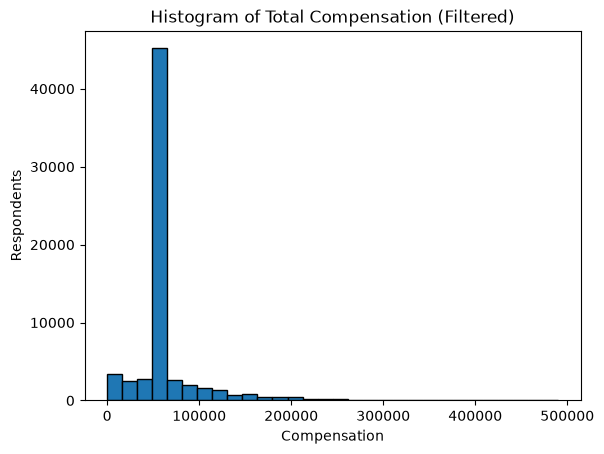

In [6]:
## Write your code here
filtered_df = df[df['ConvertedCompYearly'] < 500000]

filtered_df['ConvertedCompYearly'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Histogram of Total Compensation (Filtered)')
plt.ylabel('Respondents')
plt.xlabel('Compensation')
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [7]:
midpoint = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old':29.5,
    '35-44 years old':39.5,
    '45-54 years old':49.5,
    '55-64 years old':59.5,
    '65 years or older':70,
    'Prefer not to say':np.nan
}
df['Age'] = df['Age'].map(midpoint)

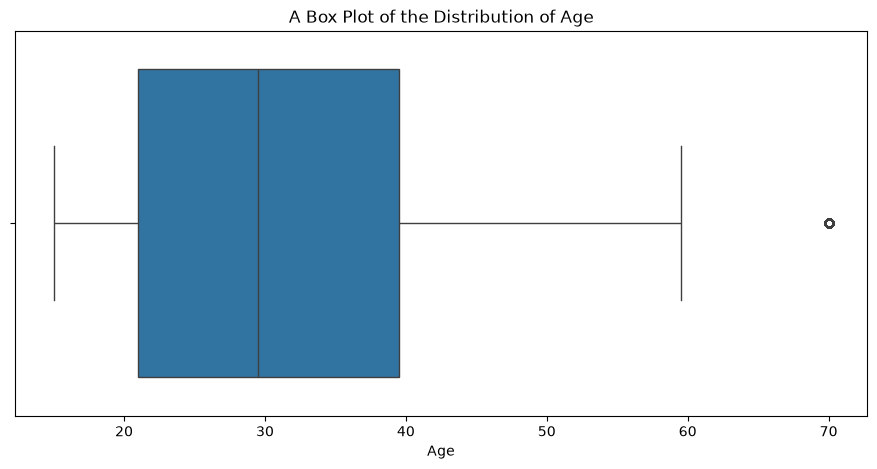

In [8]:
## Write your code here
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='Age')
plt.title('A Box Plot of the Distribution of Age')
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



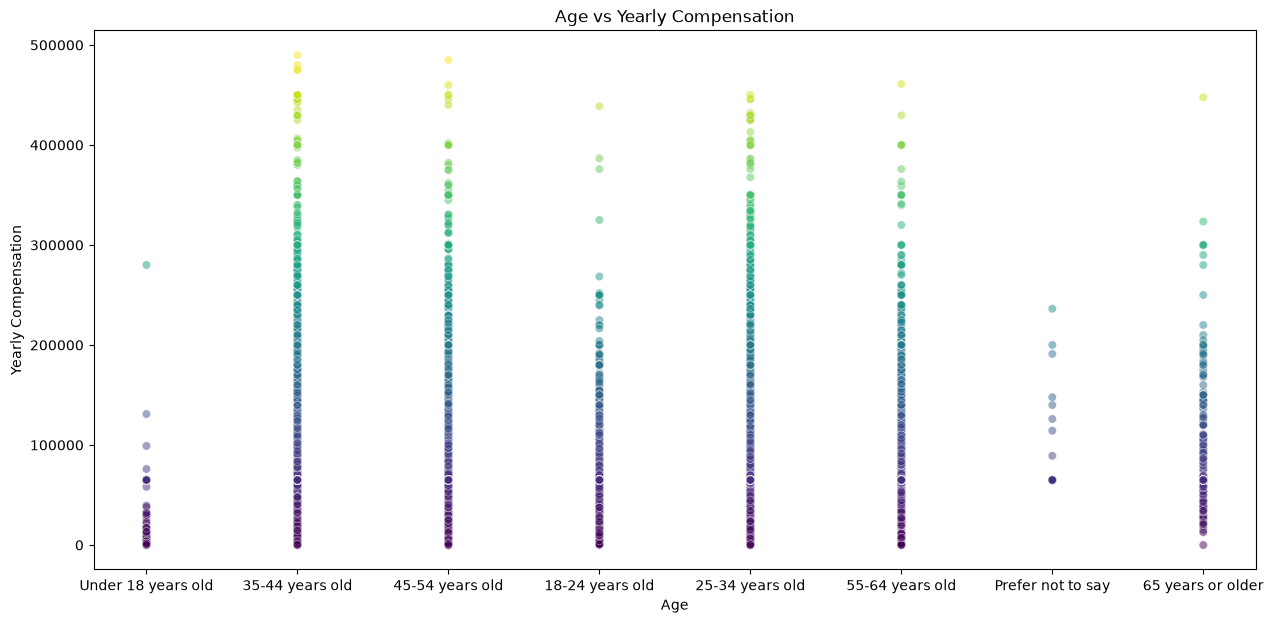

In [9]:
## Write your code here
plt.figure(figsize=(15, 7))
sns.scatterplot(
    data=filtered_df,
    x="Age",
    y="ConvertedCompYearly",
    hue="ConvertedCompYearly",
    palette="viridis",
    alpha=0.5,
    legend=False
)

plt.title("Age vs Yearly Compensation")
plt.ylabel('Yearly Compensation')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


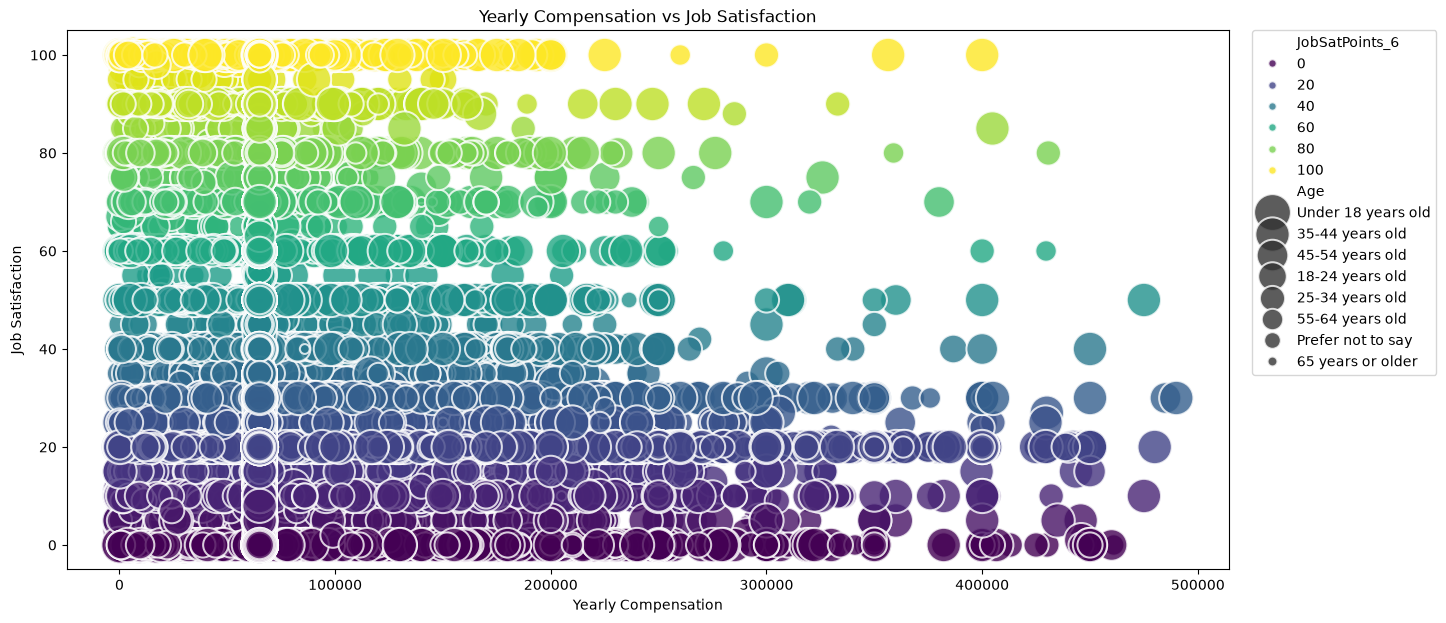

In [10]:
## Write your code here
plt.figure(figsize=(15, 7))
sns.scatterplot(
    data=filtered_df,
    x="ConvertedCompYearly",
    y="JobSatPoints_6",
    size = 'Age',
    sizes=(50, 700),
    hue="JobSatPoints_6",
    palette="viridis",
    alpha=0.8,
    legend=True
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.title("Yearly Compensation vs Job Satisfaction")
plt.ylabel('Job Satisfaction')
plt.xlabel('Yearly Compensation')
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



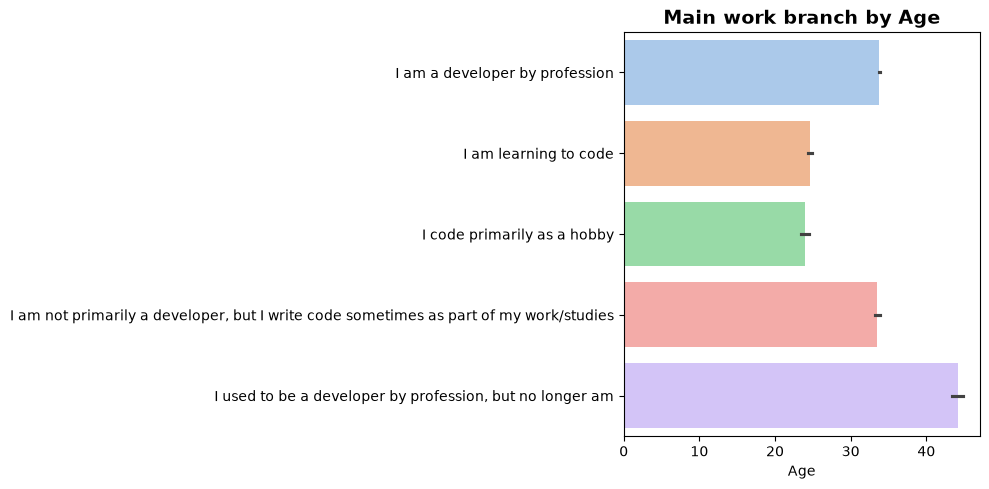

In [11]:
## Write your code here
plt.figure(figsize=(10, 5))

sns.barplot(data=df, x='Age', y='MainBranch', hue='MainBranch', palette="pastel", legend=False)

plt.title("Main work branch by Age", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("")
plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



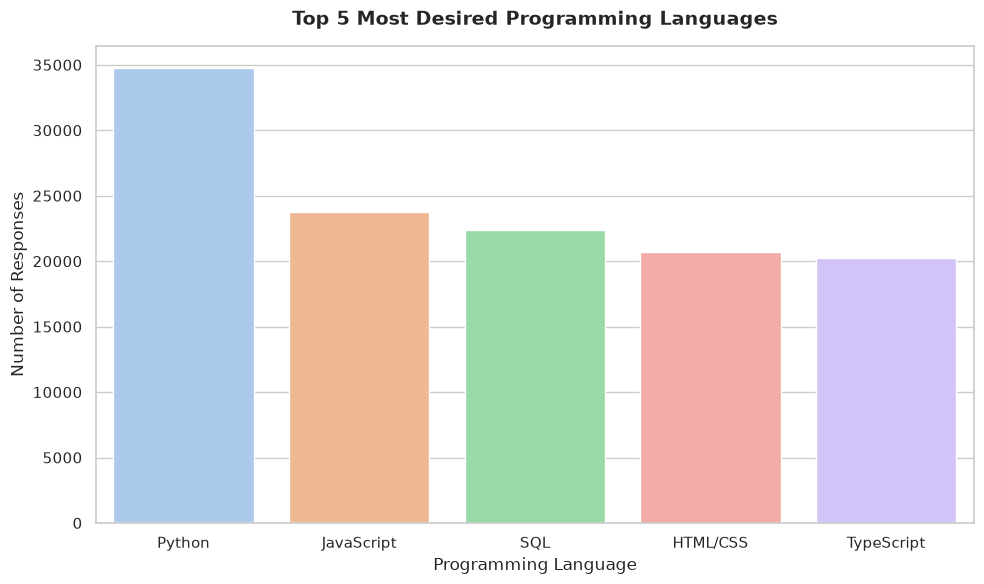

In [13]:
## Write your code here
df_lan = df.copy()
df_lan['LanguageWantToWorkWith'] = df_lan['LanguageWantToWorkWith'].str.split(';')
df_lan = df_lan.explode('LanguageWantToWorkWith')

df_lanplot = df_lan['LanguageWantToWorkWith'].value_counts().head(5)

plt.figure(figsize=(10, 6))

# Pass the Series index to x (text categories) and values to y (numerical counts)
# Seaborn automatically draws this VERTICALLY because x is categorical text
sns.barplot(
    x=df_lanplot.index, 
    y=df_lanplot.values, 
    hue=df_lanplot.index, 
    palette="pastel", 
    legend=False
)

plt.title("Top 5 Most Desired Programming Languages", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Programming Language", fontsize=12)
plt.ylabel("Number of Responses", fontsize=12)

plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


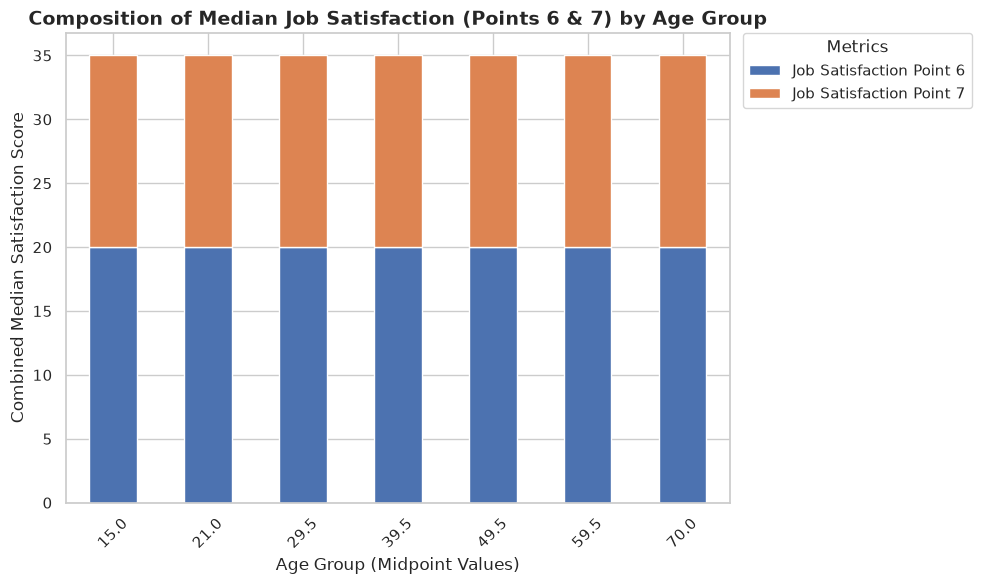

In [14]:
## Write your code here
df_jobsat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
plt.figure(figsize=(10, 6))
df_jobsat.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title("Composition of Median Job Satisfaction (Points 6 & 7) by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group (Midpoint Values)")
plt.ylabel("Combined Median Satisfaction Score")
plt.xticks(rotation=45)
plt.legend(["Job Satisfaction Point 6", "Job Satisfaction Point 7"], title="Metrics", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



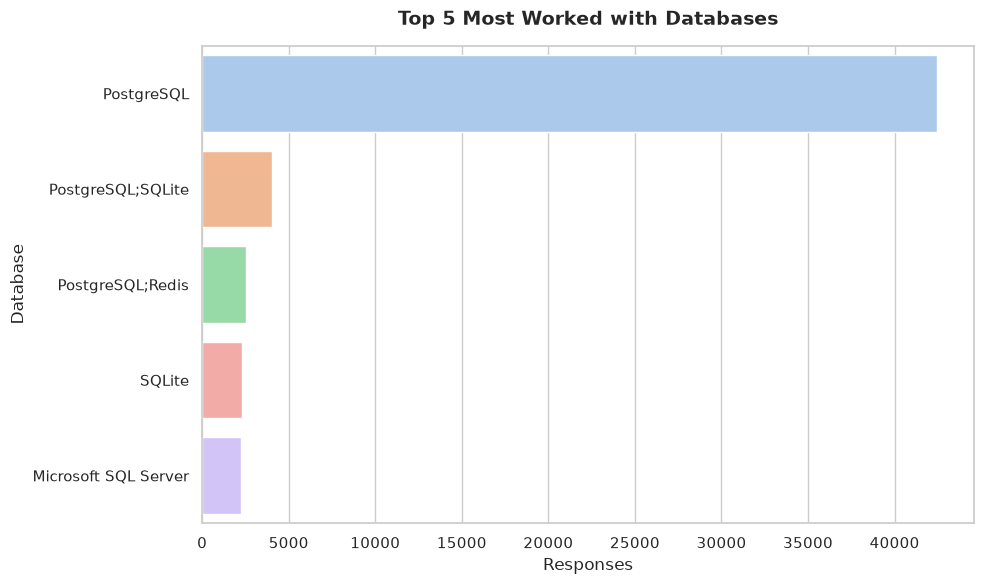

In [18]:
## Write your code here
df_db = df.copy()
df_db["DatabaseHaveWorkedWith"] = df_db["DatabaseHaveWorkedWith"].str.split(";")
df_db = df_db.explode("DatabaseHaveWorkedWith")

df_top5db = df_db["DatabaseWantToWorkWith"].value_counts().head()


plt.figure(figsize=(10, 6))

# Pass the Series index to x (text categories) and values to y (numerical counts)
# Seaborn automatically draws this VERTICALLY because x is categorical text
sns.barplot(
    x=df_top5db.values, 
    y=df_top5db.index, 
    hue=df_top5db.index, 
    palette="pastel", 
    legend=False
)

plt.title("Top 5 Most Worked with Databases", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Responses", fontsize=12)
plt.ylabel("Database", fontsize=12)

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



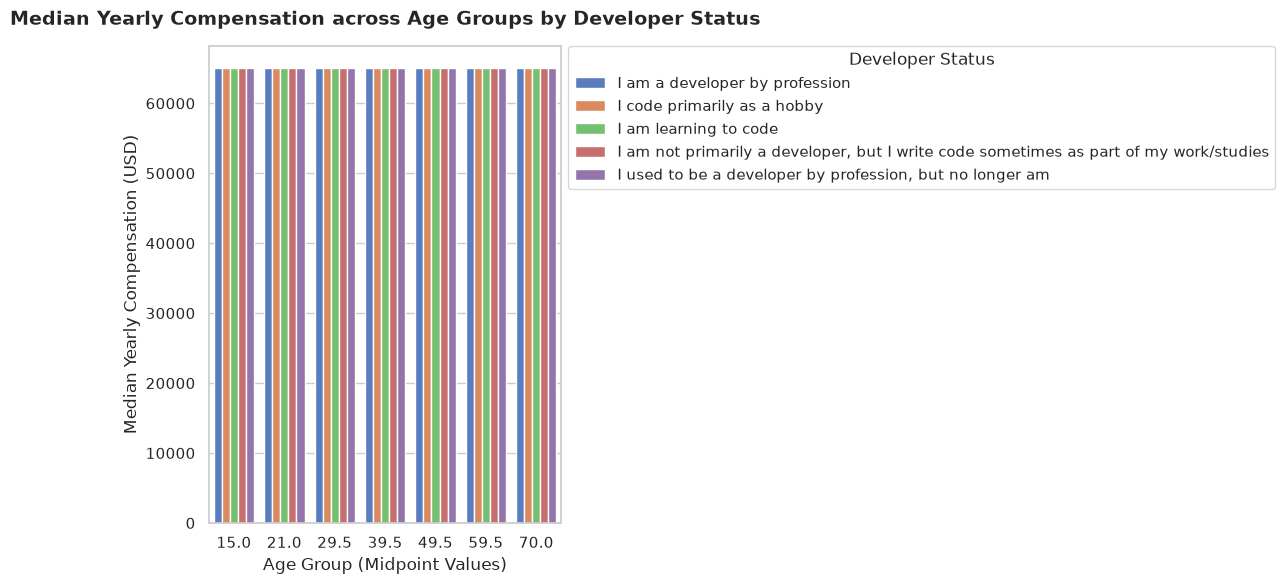

In [21]:
## Write your code here
fig, ax = plt.subplots(figsize=(12, 6))

#GROUPED BAR CHART: 'hue' forces the categories to stand side-by-side
sns.barplot(
    data=df,
    x='Age',                          # Main horizontal categories (Age Midpoints)
    y='ConvertedCompYearly',          # Dependent numerical value on vertical axis
    hue='MainBranch',                 # Sub-group splitter column for side-by-side bars
    estimator=np.median,              # Explicitly calculates median to handle salary outliers
    errorbar=None,                    # Removes confidence interval lines for maximum visual clarity
    palette="muted",
    ax=ax
)

plt.title("Median Yearly Compensation across Age Groups by Developer Status", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Age Group (Midpoint Values)", fontsize=12)
plt.ylabel("Median Yearly Compensation (USD)", fontsize=12)
plt.xticks(rotation=0) 

plt.legend(title="Developer Status", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



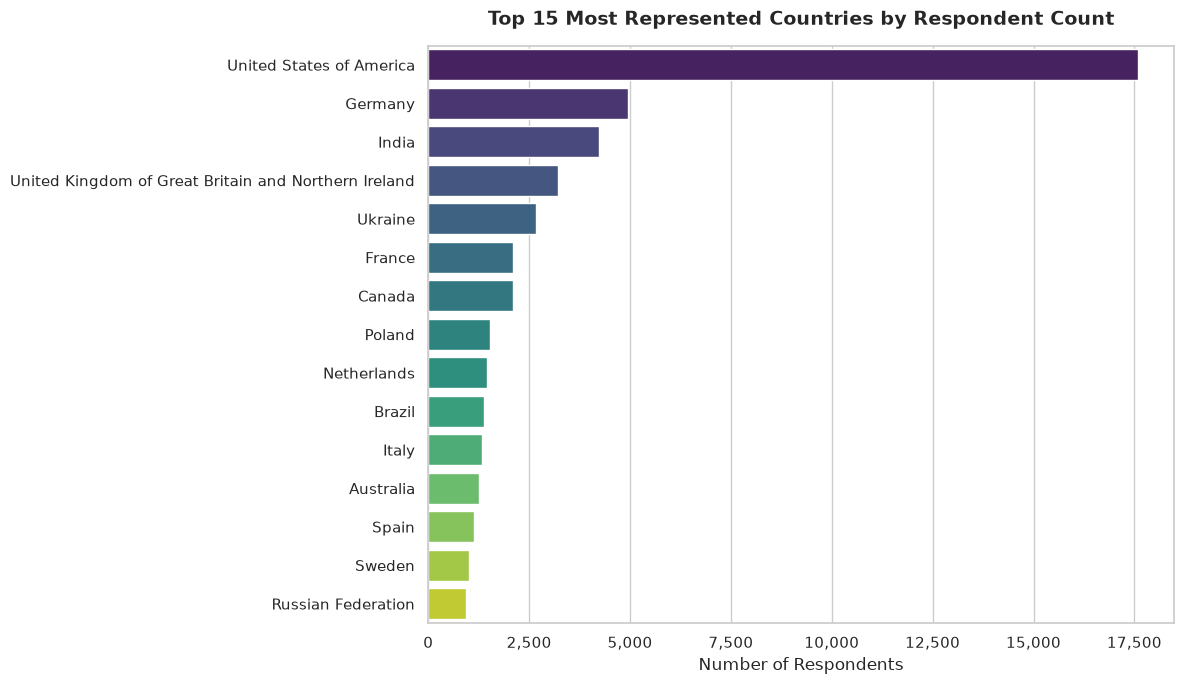

In [22]:
## Write your code here
top_countries = df['Country'].value_counts().head(15).reset_index()

#Rename columns clearly: 'Country' becomes our labels, 'count' becomes our values
top_countries.columns = ['Country', 'Respondent Count']

# 2. Initialize the plotting canvas using subplots
fig, ax = plt.subplots(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 3. HORIZONTAL BAR CHART: Numeric values on X, Categorical labels on Y
# Seaborn automatically draws this horizontally because of the type assignments
sns.barplot(
    data=top_countries,
    x='Respondent Count',  # Numerical values determine bar length horizontally
    y='Country',           # Categorical labels stack vertically on the left
    hue='Country',         # Set hue to match the labels for a clean aesthetic
    palette="viridis",     # Viridis provides a beautiful, modern color gradient
    legend=False,
    ax=ax
)

# 4. Refine presentation text and formatting labels
plt.title("Top 15 Most Represented Countries by Respondent Count", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Respondents", fontsize=12)
plt.ylabel("")  # Clear the Y label because the country strings are self-explanatory

# Format the horizontal X-axis numbers to display thousand-commas cleanly (e.g., 25,000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
